# **Transfer Learning in PyTorch: Advanced Techniques for Leveraging Pre-trained Models**

**Course:** Generative AI and Deep Learning
**Institution:** IIT Madras  
**Author:** Prof. Ganapathy Krishnamurthi  
**Date:** September 2025

---

## **Learning Objectives**

By the end of this tutorial, students will be able to:

1. **Understand** the theoretical foundations and mathematical principles underlying transfer learning
2. **Implement** transfer learning strategies using pre-trained PyTorch models for computer vision tasks
3. **Apply** feature extraction and fine-tuning methodologies for domain adaptation
4. **Evaluate** the effectiveness of transfer learning compared to training from scratch
5. **Analyze** the impact of pre-trained model selection on downstream task performance
6. **Design** transfer learning pipelines for novel computer vision applications

---

## **Prerequisites**

- Proficiency in PyTorch fundamentals and neural network implementation
- Understanding of convolutional neural networks (CNNs)
- Knowledge of computer vision concepts and image classification methodologies
- Familiarity with gradient descent optimization and backpropagation algorithms

## **1 Overview and Theoretical Framework**

### **1.1 Introduction to Transfer Learning**

**Transfer learning represents a paradigm shift in machine learning that enables the adaptation of knowledge from one domain to another.** This methodology addresses one of the fundamental challenges in deep learning: the requirement for large-scale labeled datasets and extensive computational resources for training effective models from scratch.

### **1.2 Mathematical Foundation of Transfer Learning**

Transfer learning operates on the principle that learned representations from source domains can be effectively adapted to target domains. Formally, let:

- **S = {(x_s, y_s)}**: Source domain dataset
- **T = {(x_t, y_t)}**: Target domain dataset  
- **f_θ**: Neural network with parameters θ
- **φ(x)**: Feature representation function

The transfer learning objective seeks to minimize:

**L_transfer = L_target(f_φ(x_t), y_t) + λ * R(φ)**

Where:
- **L_target**: Loss function on target domain
- **R(φ)**: Regularization term preserving source domain knowledge
- **λ**: Balance parameter between adaptation and preservation

### **1.3 Pedagogical Approach and Learning Outcomes**

This tutorial demonstrates transfer learning through practical implementation using PyTorch's torchvision library, specifically leveraging models pre-trained on ImageNet. The methodology presented encompasses both **feature extraction** and **fine-tuning** strategies, providing students with comprehensive understanding of modern transfer learning practices.

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/06-transfer-learning-example-overview.png" alt="transfer learning overview on different problems" width=900/>

*Figure 1.1: Conceptual framework of transfer learning across different domains. Pre-trained models learn generalizable feature representations that can be adapted to novel tasks with limited domain-specific data.*

### **1.4 Theoretical Justification for Transfer Learning**

Transfer learning addresses several critical challenges in modern machine learning:

#### **1.4.1 Data Efficiency and Computational Resource Optimization**

1. **Reduced Data Requirements**: Leverages existing knowledge to achieve high performance with limited target domain data
2. **Computational Efficiency**: Eliminates the need for training large networks from random initialization
3. **Convergence Acceleration**: Pre-trained features provide superior initialization points for optimization

#### **1.4.2 Knowledge Transfer Mechanisms**

| **Transfer Strategy** | **Methodology** | **Use Case** | **Computational Requirements** |
|---------------------|-----------------|--------------|------------------------------|
| **Feature Extraction** | Freeze pre-trained layers, train only classifier | Small target datasets | Low computational cost |
| **Fine-tuning** | Update all parameters with reduced learning rates | Moderate target datasets | Medium computational cost |
| **Progressive Fine-tuning** | Gradual unfreezing of network layers | Large target datasets | High computational cost |

#### **1.4.3 Empirical Evidence and Research Validation**

Recent research consistently demonstrates the superiority of transfer learning over training from scratch. Key findings include:

1. **Performance Gains**: Significant improvement in classification accuracy with limited training data
2. **Training Efficiency**: Reduced training time and computational resource requirements
3. **Generalization Capability**: Enhanced model robustness across diverse target domains

## **2 Implementation Framework and Experimental Design**

### **2.1 Experimental Design and Dataset Selection**

This tutorial implements transfer learning for multi-class image classification using the **FoodVision Mini dataset**, which consists of three food categories: pizza, steak, and sushi. This controlled experimental design enables systematic evaluation of transfer learning effectiveness while maintaining computational tractability.

#### **2.1.1 Dataset Characteristics**

The FoodVision Mini dataset provides an ideal testbed for transfer learning evaluation due to:

1. **Moderate Complexity**: Three-class classification problem with sufficient inter-class variation
2. **Visual Richness**: High-resolution color images with diverse backgrounds and presentations
3. **Domain Relevance**: Food images represent a practical application domain for computer vision
4. **Computational Feasibility**: Dataset size enables rapid experimentation and iterative development

#### **2.1.2 Transfer Learning Hypothesis**

**Primary Hypothesis:** Pre-trained convolutional features from ImageNet will provide superior performance compared to training from scratch, especially with limited training data.

**Secondary Hypothesis:** Fine-tuning strategies will outperform feature extraction approaches when sufficient computational resources are available.

### **2.2 Tutorial Outline**

We're going to take a pretrained model from `torchvision.models` and customise it to work on (and hopefully improve) our FoodVision Mini problem.

| **Topic** | **Contents** |
| ----- | ----- |
| **1. Get data** | Let's get the pizza, steak and sushi image classification dataset. |
| **2. Create Datasets and DataLoaders** | Create dataset and dataloaders for the task. |
| **3. Get and customise a pretrained model** | Download a pretrained model from `torchvision.models` and customise it to our problem. |
| **4. Train model** | Finetue the pretrained model on our pizza, steak, sushi dataset. |
| **5. Evaluate the model by plotting loss curves** | How did our first transfer learning model go? Did it overfit or underfit?  |

### **2.3 Dataset Preparation**

In [1]:
# Import Essential Libraries for Transfer Learning Implementation
# ============================================================

# Core PyTorch libraries for deep learning and neural network construction
import torch
from torch import nn

# Computer vision utilities and pre-trained models
import torchvision
from torchvision import transforms

# Data manipulation and visualization libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from typing import Dict, List, Tuple

# System and utility libraries
import os
import requests
from pathlib import Path

# Verify PyTorch installation and system configuration
print(f"PyTorch Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")

# Display CUDA availability for GPU acceleration
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Available GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Set default device for tensor operations
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

PyTorch Version: 2.10.0+cpu
Torchvision Version: 0.25.0+cpu
CUDA Available: False
Using device: cpu


In [2]:
# Dataset Acquisition and Preparation
# ===================================

def download_data(source: str,
                  destination: str,
                  remove_source: bool = True) -> Path:
    """
    Download and extract dataset from URL source.

    This function implements automated dataset acquisition with proper
    error handling and file management for reproducible experiments.

    Args:
        source (str): URL path to the dataset archive
        destination (str): Local directory path for data storage
        remove_source (bool): Whether to remove compressed file after extraction

    Returns:
        Path: Path object pointing to the extracted dataset directory

    Raises:
        requests.RequestException: If download fails
        FileNotFoundError: If extraction fails
    """

    # Create destination directory if it doesn't exist
    data_path = Path("data/")
    image_path = data_path / destination

    if image_path.is_dir():
        print(f"[INFO] Dataset already exists at {image_path}")
        return image_path

    # Create directory structure
    image_path.mkdir(parents=True, exist_ok=True)

    # Download and extract dataset
    target_file = Path(source).name

    with open(data_path / target_file, "wb") as f:
        request = requests.get(source)
        print(f"[INFO] Downloading {target_file} from {source}")
        f.write(request.content)

    # Extract compressed archive
    with zipfile.ZipFile(data_path / target_file, "r") as zip_ref:
        print(f"[INFO] Extracting {target_file}")
        zip_ref.extractall(image_path)

    # Clean up compressed file if requested
    if remove_source:
        os.remove(data_path / target_file)

    return image_path

# Acquire FoodVision Mini Dataset
import zipfile

# Dataset URL from course materials
FOOD_VISION_URL = "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip"

# Download and prepare dataset
data_dir = download_data(source=FOOD_VISION_URL,
                        destination="pizza_steak_sushi")

print(f"[SUCCESS] Dataset prepared at: {data_dir}")

[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip
[INFO] Extracting pizza_steak_sushi.zip
[SUCCESS] Dataset prepared at: data\pizza_steak_sushi


### **2.4 Dataset Analysis and Exploration**

#### **2.4.1 Dataset Statistics and Class Distribution Analysis**

Comprehensive dataset analysis provides insights into class balance, sample distribution, and potential preprocessing requirements. This statistical foundation enables informed hyperparameter selection and training strategy optimization.

In [5]:
# Comprehensive Dataset Statistics and Analysis
# ============================================

def compute_dataset_statistics(data_path: Path) -> dict:
    """
    Calculate comprehensive statistics for the image classification dataset.

    This function provides detailed analysis of class distribution, sample counts,
    and dataset partitioning to inform experimental design decisions.

    Args:
        data_path (Path): Root directory containing train/test subdirectories

    Returns:
        dict: Complete dataset statistics including counts and distributions
    """

    statistics = {
        'total_samples': 0,
        'class_statistics': {},
        'split_statistics': {}
    }

    # Define dataset splits and class names
    splits = ['train', 'test']
    class_names = []

    print("=== DATASET STATISTICS ANALYSIS ===\n")

    for split in splits:
        split_path = data_path / split
        if not split_path.exists():
            print(f"[WARNING] Split directory {split} not found")
            continue

        split_total = 0
        split_stats = {}

        # Get class directories
        class_dirs = [d for d in split_path.iterdir() if d.is_dir()]

        for class_dir in class_dirs:
            class_name = class_dir.name
            if class_name not in class_names:
                class_names.append(class_name)

            # Count images in class directory
            image_files = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
            class_count = len(image_files)

            split_stats[class_name] = class_count
            split_total += class_count

            if class_name not in statistics['class_statistics']:
                statistics['class_statistics'][class_name] = {'train': 0, 'test': 0}

            statistics['class_statistics'][class_name][split] = class_count

        statistics['split_statistics'][split] = {
            'total': split_total,
            'classes': split_stats
        }
        statistics['total_samples'] += split_total

        print(f"{split.upper()} SET:")
        for class_name, count in split_stats.items():
            print(f"  {class_name}: {count} samples")
        print(f"  Total: {split_total} samples\n")

    # Calculate class balance metrics
    print("CLASS BALANCE ANALYSIS:")
    for class_name in class_names:
        train_count = statistics['class_statistics'][class_name]['train']
        test_count = statistics['class_statistics'][class_name]['test']
        total_count = train_count + test_count
        train_ratio = train_count / total_count if total_count > 0 else 0

        print(f"{class_name}:")
        print(f"  Total: {total_count} samples")
        print(f"  Train/Test ratio: {train_ratio:.3f}/{1-train_ratio:.3f}")

    print(f"\nOVERALL DATASET:")
    print(f"Total samples: {statistics['total_samples']}")
    print(f"Number of classes: {len(class_names)}")
    print(f"Classes: {class_names}")

    return statistics

# Execute comprehensive dataset analysis
dataset_stats = compute_dataset_statistics(data_dir)

=== DATASET STATISTICS ANALYSIS ===

TRAIN SET:
  pizza: 78 samples
  steak: 75 samples
  sushi: 72 samples
  Total: 225 samples

TEST SET:
  pizza: 25 samples
  steak: 19 samples
  sushi: 31 samples
  Total: 75 samples

CLASS BALANCE ANALYSIS:
pizza:
  Total: 103 samples
  Train/Test ratio: 0.757/0.243
steak:
  Total: 94 samples
  Train/Test ratio: 0.798/0.202
sushi:
  Total: 103 samples
  Train/Test ratio: 0.699/0.301

OVERALL DATASET:
Total samples: 300
Number of classes: 3
Classes: ['pizza', 'steak', 'sushi']


#### **2.4.2 Data Visualization**

In [25]:
# Visualize Sample Images from the Dataset Folder
# =============================================

import random
from PIL import Image
import torch

def visualize_sample_images_from_folder(data_path: Path, class_names: list, transform: transforms.Compose, mean: list, std: list, num_images_to_plot: int = 3):
    """
    Visualize a few sample images directly from the dataset folder with their class labels.

    This function provides a visual inspection of the raw dataset images before DataLoader processing.

    Args:
        data_path (Path): Root directory containing train/test subdirectories.
        class_names (list): List of class names.
        transform (transforms.Compose): Transformation pipeline to apply to the images.
        mean (list): List of mean values for normalization (e.g., ImageNet mean).
        std (list): List of standard deviation values for normalization (e.g., ImageNet std).
        num_images_to_plot (int): Number of images to display.
    """
    plt.figure(figsize=(10, 10))

    image_paths = []
    for class_name in class_names:
        class_path = data_path / "train" / class_name  # Assume visualizing from train set
        image_paths.extend(list(class_path.glob('*.jpg')) + list(class_path.glob('*.png')))

    # Get a random sample of image paths
    random_image_paths = random.sample(image_paths, num_images_to_plot)

    for i, image_path in enumerate(random_image_paths):
        # Open image and apply transform
        image = Image.open(image_path).convert("RGB") # Ensure image is RGB
        transformed_image = transform(image)

        # Get class label from directory name
        class_name = image_path.parent.name
        label = class_names.index(class_name)

        # Unnormalize the image for visualization (assuming ImageNet normalization was applied in transform)
        unnormalized_image = transformed_image * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
        unnormalized_image = unnormalized_image.permute(1, 2, 0)  # Change from CxHxW to HxWx

        # Plot the image
        plt.subplot(1, num_images_to_plot, i + 1)
        plt.imshow(unnormalized_image)
        plt.title(class_names[label])
        plt.axis(False)

    plt.show()


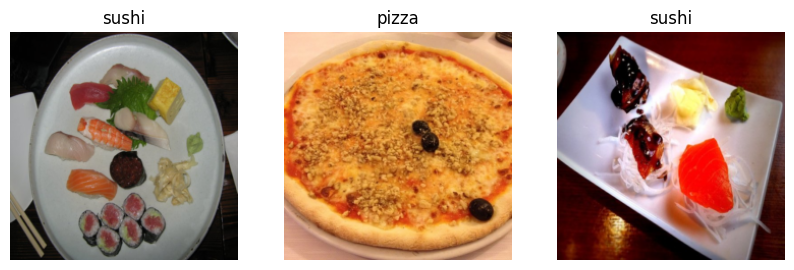

In [26]:

# Define ImageNet normalization parameters (required for pre-trained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]  # RGB channel means
IMAGENET_STD = [0.229, 0.224, 0.225]   # RGB channel standard deviations


# Visualize sample images using the dataset folder path and test transforms
# Using test_transform here as it doesn't include random augmentations
class_names = ['pizza', 'steak', 'sushi']

visualize_sample_images_from_folder(data_dir, class_names, test_transform, IMAGENET_MEAN, IMAGENET_STD, num_images_to_plot=3)

## **3 Data Loading and Preprocessing Pipeline**

### **3.1 Theoretical Foundation of Data Preprocessing**

**Data preprocessing represents a critical component in transfer learning pipelines.** Pre-trained models expect input data in specific formats and value ranges that match their training distributions. Proper preprocessing ensures optimal transfer of learned representations from source to target domains.

#### **3.1.1 ImageNet Preprocessing Standards**

PyTorch pre-trained models follow ImageNet preprocessing conventions:

1. **Normalization**: RGB values normalized to ImageNet mean and standard deviation
   - **Mean**: [0.485, 0.456, 0.406] (RGB channels)
   - **Standard Deviation**: [0.229, 0.224, 0.225] (RGB channels)

2. **Spatial Resolution**: Input images resized to 224×224 pixels (standard for most architectures)

3. **Data Augmentation**: Systematic transformations to improve model generalization

#### **3.1.2 Mathematical Framework of Data Transforms**

The preprocessing pipeline implements the following mathematical operations:

**Normalization:** x_norm = (x - μ) / σ

Where:
- **x**: Original pixel values [0, 255]
- **μ**: Channel-wise mean vector
- **σ**: Channel-wise standard deviation vector
- **x_norm**: Normalized pixel values

#### **3.1.3 Transfer Learning Preprocessing Strategy**

| **Transform Type** | **Training Set** | **Test Set** | **Rationale** |
|-------------------|------------------|--------------|---------------|
| **Resize** | 224×224 | 224×224 | Match pre-trained model input requirements |
| **Data Augmentation** | Random flips, rotations | None | Increase training data diversity |
| **Normalization** | ImageNet statistics | ImageNet statistics | Preserve pre-trained feature distributions |
| **Tensor Conversion** | ToTensor() | ToTensor() | Convert PIL images to PyTorch tensors |

In [28]:
# Data Preprocessing Pipeline Implementation
# ========================================

from torchvision import transforms

def create_transform_pipelines():
    """
    Create standardized data transformation pipelines for transfer learning.

    This function implements the recommended preprocessing strategies for
    transfer learning with ImageNet pre-trained models, ensuring optimal
    feature transfer and model performance.

    Returns:
        tuple: Training and testing transform pipelines

    Note:
        - Training transforms include data augmentation for improved generalization
        - Testing transforms focus on consistent preprocessing without augmentation
        - All transforms follow ImageNet normalization standards
    """

    # ImageNet normalization parameters (required for pre-trained models)
    IMAGENET_MEAN = [0.485, 0.456, 0.406]  # RGB channel means
    IMAGENET_STD = [0.229, 0.224, 0.225]   # RGB channel standard deviations

    # Training data transforms with augmentation
    train_transforms = transforms.Compose([
        transforms.Resize((224, 224)),                    # Resize to standard input size
        transforms.RandomHorizontalFlip(p=0.5),          # Random horizontal flip (50% probability)
        transforms.RandomRotation(degrees=10),           # Random rotation (±10 degrees)
        transforms.ColorJitter(brightness=0.2,           # Color augmentation
                              contrast=0.2,
                              saturation=0.2,
                              hue=0.1),
        transforms.ToTensor(),                            # Convert PIL image to tensor [0,1]
        transforms.Normalize(mean=IMAGENET_MEAN,          # Normalize using ImageNet statistics
                           std=IMAGENET_STD)
    ])

    # Testing data transforms (no augmentation)
    test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),                    # Resize to standard input size
        transforms.ToTensor(),                            # Convert PIL image to tensor [0,1]
        transforms.Normalize(mean=IMAGENET_MEAN,          # Normalize using ImageNet statistics
                           std=IMAGENET_STD)
    ])

    return train_transforms, test_transforms

# Create transform pipelines
train_transform, test_transform = create_transform_pipelines()

print("=== DATA PREPROCESSING PIPELINE CONFIGURATION ===")
print(f"Training transforms: {len(train_transform.transforms)} operations")
print(f"Testing transforms: {len(test_transform.transforms)} operations")
print("\nTraining pipeline:")
for i, transform in enumerate(train_transform.transforms, 1):
    print(f"  {i}. {transform}")
print("\nTesting pipeline:")
for i, transform in enumerate(test_transform.transforms, 1):
    print(f"  {i}. {transform}")

=== DATA PREPROCESSING PIPELINE CONFIGURATION ===
Training transforms: 6 operations
Testing transforms: 3 operations

Training pipeline:
  1. Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
  2. RandomHorizontalFlip(p=0.5)
  3. RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
  4. ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.1, 0.1))
  5. ToTensor()
  6. Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

Testing pipeline:
  1. Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
  2. ToTensor()
  3. Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


### **3.2 Dataset Objects and DataLoader Implementation**

**PyTorch's Dataset and DataLoader classes provide a standardized interface for efficient data loading and batch processing.** The ImageFolder dataset class automatically creates class labels from directory structure, simplifying the implementation of image classification pipelines.

#### **3.2.1 ImageFolder Dataset Methodology**

The ImageFolder class implements the following systematic approach:

1. **Automatic Label Assignment**: Directory names become class labels
2. **Efficient File Indexing**: Creates internal mapping of image paths to labels  
3. **Transform Integration**: Applies preprocessing transformations during data loading
4. **Memory Management**: Loads images on-demand to optimize memory usage

In [29]:
# Dataset and DataLoader Implementation
# ====================================

from torchvision import datasets
from torch.utils.data import DataLoader

def create_datasets_and_dataloaders(data_dir: Path,
                                  train_transform: transforms.Compose,
                                  test_transform: transforms.Compose,
                                  batch_size: int = 32,
                                  num_workers: int = 0,
                                  shuffle_train: bool = True) -> tuple:
    """
    Create PyTorch Dataset objects and DataLoader instances for efficient data handling.

    This function implements the standard PyTorch data loading pipeline using
    ImageFolder datasets for automatic label creation and efficient batch processing.

    Args:
        data_dir (Path): Root directory containing train/test subdirectories
        train_transform (transforms.Compose): Training data preprocessing pipeline
        test_transform (transforms.Compose): Testing data preprocessing pipeline
        batch_size (int): Number of samples per batch for gradient computation
        num_workers (int): Number of worker processes for data loading
        shuffle_train (bool): Whether to shuffle training data between epochs

    Returns:
        tuple: (train_dataset, test_dataset, train_dataloader, test_dataloader, class_names)
    """

    # Create Dataset objects using ImageFolder
    train_dataset = datasets.ImageFolder(root=data_dir / "train",
                                        transform=train_transform)

    test_dataset = datasets.ImageFolder(root=data_dir / "test",
                                       transform=test_transform)

    # Extract class names from dataset
    class_names = train_dataset.classes

    # Create DataLoader objects for batch processing
    train_dataloader = DataLoader(dataset=train_dataset,
                                 batch_size=batch_size,
                                 shuffle=shuffle_train,
                                 num_workers=num_workers,
                                 pin_memory=True if device == "cuda" else False)

    test_dataloader = DataLoader(dataset=test_dataset,
                                batch_size=batch_size,
                                shuffle=False,  # No shuffling for consistent evaluation
                                num_workers=num_workers,
                                pin_memory=True if device == "cuda" else False)

    return train_dataset, test_dataset, train_dataloader, test_dataloader, class_names

# Initialize datasets and dataloaders
train_dataset, test_dataset, train_dataloader, test_dataloader, class_names = create_datasets_and_dataloaders(
    data_dir=data_dir,
    train_transform=train_transform,
    test_transform=test_transform,
    batch_size=32,
    num_workers=2
)

print("=== DATASET AND DATALOADER SUMMARY ===")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")
print(f"Number of classes: {len(class_names)}")
print(f"Class names: {class_names}")
print(f"Batch size: {train_dataloader.batch_size}")
print(f"Training batches per epoch: {len(train_dataloader)}")
print(f"Testing batches: {len(test_dataloader)}")

=== DATASET AND DATALOADER SUMMARY ===
Training samples: 225
Testing samples: 75
Number of classes: 3
Class names: ['pizza', 'steak', 'sushi']
Batch size: 32
Training batches per epoch: 8
Testing batches: 3


## **4 Pretrained Model**

### **4.1 Getting a pretrained model**

The whole idea of transfer learning is to **take an already well-performing model on a problem-space similar to yours and then customise it to your use case**.

Since we're working on a computer vision problem (image classification with FoodVision Mini), we can find pretrained classification models in [`torchvision.models`](https://pytorch.org/vision/stable/models.html#classification).

Exploring the documentation, you'll find plenty of common computer vision architecture backbones such as:

| **Architecuture backbone** | **Code** |
| ----- | ----- |
| [ResNet](https://arxiv.org/abs/1512.03385)'s | `torchvision.models.resnet18()`, `torchvision.models.resnet50()`... |
| [VGG](https://arxiv.org/abs/1409.1556) (similar to what we used for TinyVGG) | `torchvision.models.vgg16()` |
| [EfficientNet](https://arxiv.org/abs/1905.11946)'s | `torchvision.models.efficientnet_b0()`, `torchvision.models.efficientnet_b1()`... |
| [VisionTransformer](https://arxiv.org/abs/2010.11929) (ViT's)| `torchvision.models.vit_b_16()`, `torchvision.models.vit_b_32()`... |
| [ConvNeXt](https://arxiv.org/abs/2201.03545) | `torchvision.models.convnext_tiny()`,  `torchvision.models.convnext_small()`... |
| More available in `torchvision.models` | `torchvision.models...` |

### **4.2 Which pretrained model should you use?**

It depends on your problem/the device you're working with. **Some better performing models are too big for some devices**.

For example, say you'd like to run your model on a mobile-device, you'll have to take into account the limited compute resources on the device, thus you'd be looking for a smaller model. Understanding this **performance vs. speed vs. size** tradeoff will come with time and practice.

In this tutorial, we will be using **EfficientNet-B0 model**

### **4.3 Setting up a pretrained model**



The pretrained model we're going to be using is [`torchvision.models.efficientnet_b0()`](https://pytorch.org/vision/main/models/generated/torchvision.models.efficientnet_b0.html).

The architecture is from the paper *[EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks](https://arxiv.org/abs/1905.11946)*.

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/06-effnet-b0-feature-extractor.png" alt="efficienet_b0 from PyTorch torchvision feature extraction model" width=900/>

*Example of what we're going to create, a pretrained [`EfficientNet_B0` model](https://ai.googleblog.com/2019/05/efficientnet-improving-accuracy-and.html) from `torchvision.models` with the output layer adjusted for our use case of classifying pizza, steak and sushi images.*

In [30]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # .DEFAULT = best available weights
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

model

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:02<00:00, 10.5MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Our `efficientnet_b0` comes in three main parts:
1. `features` - A collection of convolutional layers and other various activation layers to learn a base representation of vision data (this base representation/collection of layers is often referred to as **features** or **feature extractor**, "the base layers of the model learn the different **features** of images").
2. `avgpool` - Takes the average of the output of the `features` layer(s) and turns it into a **feature vector**.
3. `classifier` - Turns the **feature vector** into a vector with the same dimensionality as the number of required output classes (since `efficientnet_b0` is pretrained on ImageNet and because ImageNet has 1000 classes, `out_features=1000` is the default).

To learn more about our model, let's use `torchsummary`'s [`summary()` method](https://pypi.org/project/torch-summary/).

To do so, we'll pass in:
 * `model` - the model we'd like to get a summary of.
 * `input_size` - the shape of the data we'd like to pass to our model, for the case of `efficientnet_b0`, the input size is `(3, 224, 224)`, though [other variants of `efficientnet_bX` have different input sizes](https://github.com/pytorch/vision/blob/d2bfd639e46e1c5dc3c177f889dc7750c8d137c7/references/classification/train.py#L92-L93).

In [32]:
!pip install torchsummary
from torchsummary import summary

summary(model=model, input_size=(3, 224, 224))

Defaulting to user installation because normal site-packages is not writeable
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13     

### **4.4 Freezing the base model and changing the output layer to suit our needs**

The process of transfer learning usually goes: freeze some base layers of a pretrained model (typically the `features` section) and then adjust the output layers (also called head/classifier layers) to suit your needs.


Let's freeze all of the layers/parameters in the `features` section of our `efficientnet_b0` model.

> **Note:** To *freeze* layers means to keep them how they are during training. For example, if your model has pretrained layers, to *freeze* them would be to say, "don't change any of the patterns in these layers during training, keep them how they are." In essence, we'd like to keep the pretrained weights/patterns our model has learned from ImageNet as a backbone and then only change the output layers.

We can freeze all of the layers/parameters in the `features` section by setting the attribute `requires_grad=False`.

For parameters with `requires_grad=False`, PyTorch doesn't track gradient updates and in turn, these parameters won't be changed by our optimizer during training.

In essence, a parameter with `requires_grad=False` is "untrainable" or "frozen" in place.

In [33]:
# Freeze all base layers in the "features" section of the model (the feature extractor) by setting requires_grad=False
for param in model.features.parameters():
    param.requires_grad = False

Let's now adjust the output layer or the `classifier` portion of our pretrained model to our needs.

In [34]:
# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the length of class_names (one output unit for each class)
output_shape = len(class_names)

# Recreate the classifier layer and seed it to the target device
model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape, # same number of output units as our number of classes
                    bias=True)).to(device)

In [35]:
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2d-14         [-1, 16, 1

### **4.5 Creating a transform for `torchvision.models` (auto creation)**

Note:  **The custom data going into the model should be prepared in the same way as the original training data that went into the model**.

And now to access the transforms associated with our `weights`, we can use the `transforms()` method.

This is essentially saying "get the data transforms that were used to train the `EfficientNet_B0_Weights` on ImageNet".

In [36]:
# Get the transforms used to create our pretrained weights
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

## **5. Train model**

In [37]:
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [39]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device) -> Tuple[float, float]:
    """Trains a PyTorch model for a single epoch.

    Turns a target PyTorch model to training mode and then
    runs through all of the required training steps (forward
    pass, loss calculation, optimizer step).

    Args:
    model: A PyTorch model to be trained.
    dataloader: A DataLoader instance for the model to be trained on.
    loss_fn: A PyTorch loss function to minimize.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
    A tuple of training loss and training accuracy metrics.
    In the form (train_loss, train_accuracy). For example:

    (0.1112, 0.8743)
    """
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metric across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device) -> Tuple[float, float]:
    """Tests a PyTorch model for a single epoch.

    Turns a target PyTorch model to "eval" mode and then performs
    a forward pass on a testing dataset.

    Args:
    model: A PyTorch model to be tested.
    dataloader: A DataLoader instance for the model to be tested on.
    loss_fn: A PyTorch loss function to calculate loss on the test data.
    device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
    A tuple of testing loss and testing accuracy metrics.
    In the form (test_loss, test_accuracy). For example:

    (0.0223, 0.8985)
    """
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device) -> Dict[str, List]:
    """Trains and tests a PyTorch model.

    Passes a target PyTorch models through train_step() and test_step()
    functions for a number of epochs, training and testing the model
    in the same epoch loop.

    Calculates, prints and stores evaluation metrics throughout.

    Args:
    model: A PyTorch model to be trained and tested.
    train_dataloader: A DataLoader instance for the model to be trained on.
    test_dataloader: A DataLoader instance for the model to be tested on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
    A dictionary of training and testing loss as well as training and
    testing accuracy metrics. Each metric has a value in a list for
    each epoch.
    In the form: {train_loss: [...],
              train_acc: [...],
              test_loss: [...],
              test_acc: [...]}
    For example if training for epochs=2:
             {train_loss: [2.0616, 1.0537],
              train_acc: [0.3945, 0.3945],
              test_loss: [1.2641, 1.5706],
              test_acc: [0.3400, 0.2973]}
    """
    # Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
    }

    # Make sure model on target device
    model.to(device)

    # Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device)
        test_loss, test_acc = test_step(model=model,
          dataloader=test_dataloader,
          loss_fn=loss_fn,
          device=device)

        # Print out what's happening
        print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
        )

        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    # Return the filled results at the end of the epochs
    return results

In [40]:
# Set the random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Setup training and save the results
results = train(model=model,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0795 | train_acc: 0.4336 | test_loss: 0.9544 | test_acc: 0.4564
Epoch: 2 | train_loss: 0.9541 | train_acc: 0.5820 | test_loss: 0.8534 | test_acc: 0.6723
Epoch: 3 | train_loss: 0.8544 | train_acc: 0.6797 | test_loss: 0.7072 | test_acc: 0.9072
Epoch: 4 | train_loss: 0.7961 | train_acc: 0.7188 | test_loss: 0.6865 | test_acc: 0.8655
Epoch: 5 | train_loss: 0.6514 | train_acc: 0.7656 | test_loss: 0.6094 | test_acc: 0.9072
[INFO] Total training time: 74.785 seconds


## **6. Evaluate model by plotting loss curves**

In [41]:
def plot_loss_curves(results):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

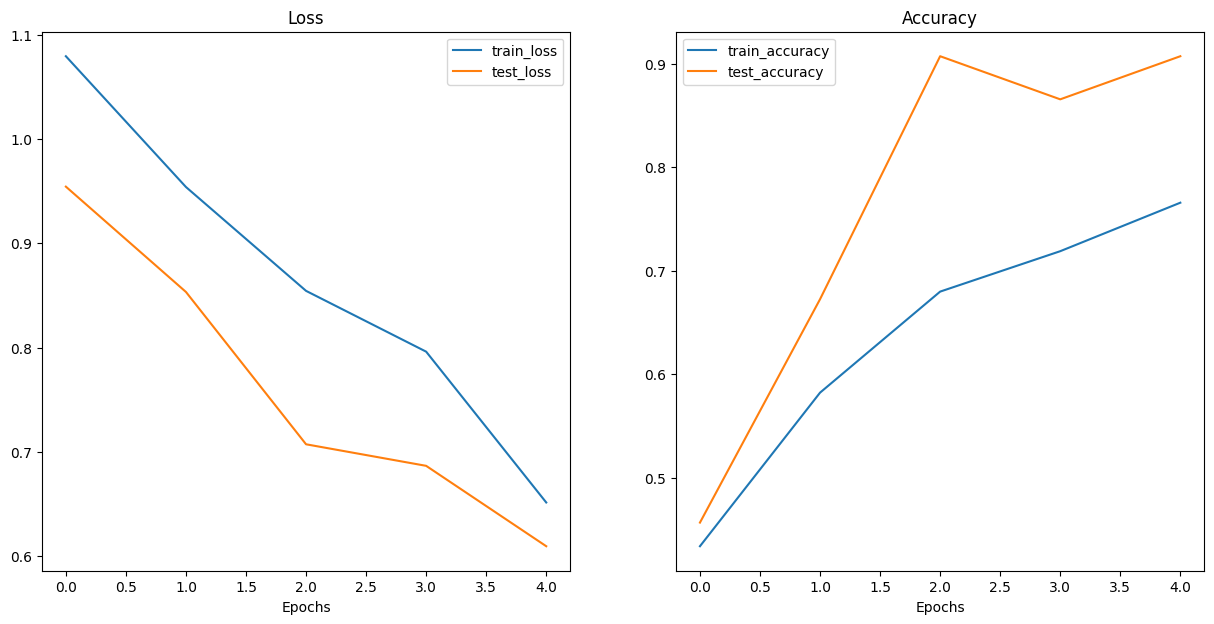

In [42]:
# Plot the loss curves of our model
plot_loss_curves(results)

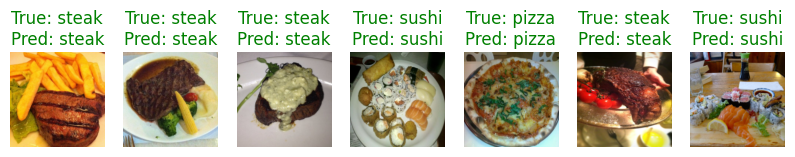

In [51]:
# Make predictions on a few random images and plot the results
# ===========================================================

import random

def predict_and_plot_images(model: torch.nn.Module,
                            dataset: torch.utils.data.Dataset,
                            class_names: list,
                            num_images_to_plot: int = 3,
                            device: torch.device = device):
    """
    Makes predictions on a few random images from a dataset and plots the results.

    Args:
        model (torch.nn.Module): Trained PyTorch model.
        dataset (torch.utils.data.Dataset): Dataset to sample images from.
        class_names (list): List of class names.
        num_images_to_plot (int): Number of images to plot.
        device (torch.device): Device to perform inference on.
    """
    model.eval()
    plt.figure(figsize=(10, 10))

    # Get random indices
    random_indices = random.sample(range(len(dataset)), k=num_images_to_plot)

    with torch.inference_mode():
        for i, idx in enumerate(random_indices):
            image, true_label = dataset[idx]
            image_on_device = image.unsqueeze(0).to(device) # Add batch dimension and send to device

            # Get prediction
            pred_logits = model(image_on_device)
            pred_prob = torch.softmax(pred_logits, dim=1)
            pred_label = torch.argmax(pred_prob, dim=1).item()

            # Unnormalize the image for visualization
            unnormalized_image = image * torch.tensor(IMAGENET_STD).view(3, 1, 1) + torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
            unnormalized_image = unnormalized_image.permute(1, 2, 0)  # Change from CxHxW to HxWx

            # Plot the image and prediction
            plt.subplot(1, num_images_to_plot, i + 1)
            plt.imshow(unnormalized_image)
            plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", color="green" if pred_label == true_label else "red")
            plt.axis(False)

    plt.show()

# Predict and plot on a few images from the test dataset
predict_and_plot_images(model=model,
                        dataset=test_dataset,
                        class_names=class_names,
                        num_images_to_plot=7,
                        device=device)